In [32]:
%run "/home/nichettg/Linux Programmi/Codici/moduli.py"

/home/nichettg/Linux Programmi/Codici/funzioni.py:200: SyntaxWarning: invalid escape sequence '\p'
  latex_file.write('\t' + '\t' +f"Equazione della retta & $y=({form(b)}\pm{form(sb)})x+({form(a)}\pm{form(sa)})$" + r"\\" + '\n')
/home/nichettg/Linux Programmi/Codici/funzioni.py:200: SyntaxWarning: invalid escape sequence '\p'
  latex_file.write('\t' + '\t' +f"Equazione della retta & $y=({form(b)}\pm{form(sb)})x+({form(a)}\pm{form(sa)})$" + r"\\" + '\n')
/home/nichettg/Linux Programmi/Codici/funzioni.py:201: SyntaxWarning: invalid escape sequence '\p'
  latex_file.write('\t' +'\t' +f"Indice Pearson & ${form(pearson_xy)}\pm{form(s_pearson_xy)}$" + r"\\" + '\n')


In [33]:
def nome (stringa):
    stringa_nuova = stringa.replace('./Data/tors_','').replace('.csv','').replace('h','H')
    return stringa_nuova

# 1. Raccolta Dati

In [34]:
input_files = [f"./Data/{nome_file}" for nome_file in sorted(os.listdir('./Data'))]
dati= {}

for i, input_file in enumerate(input_files):
    letti = pd.read_csv(input_file)

    dati[nome(input_file)] = {
        "tempo": letti["Tempo"],
        "forzante": letti["Forzante"],
        "pendolo" : letti["Pendolo"],
        "ampiezza" : letti["Ampiezza"],
        "fase" : letti["Fase"],
    }

In [35]:
gf.display_dizionario(dati)

# 2. Grafici

## 2.1 Confronto Frequenze

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


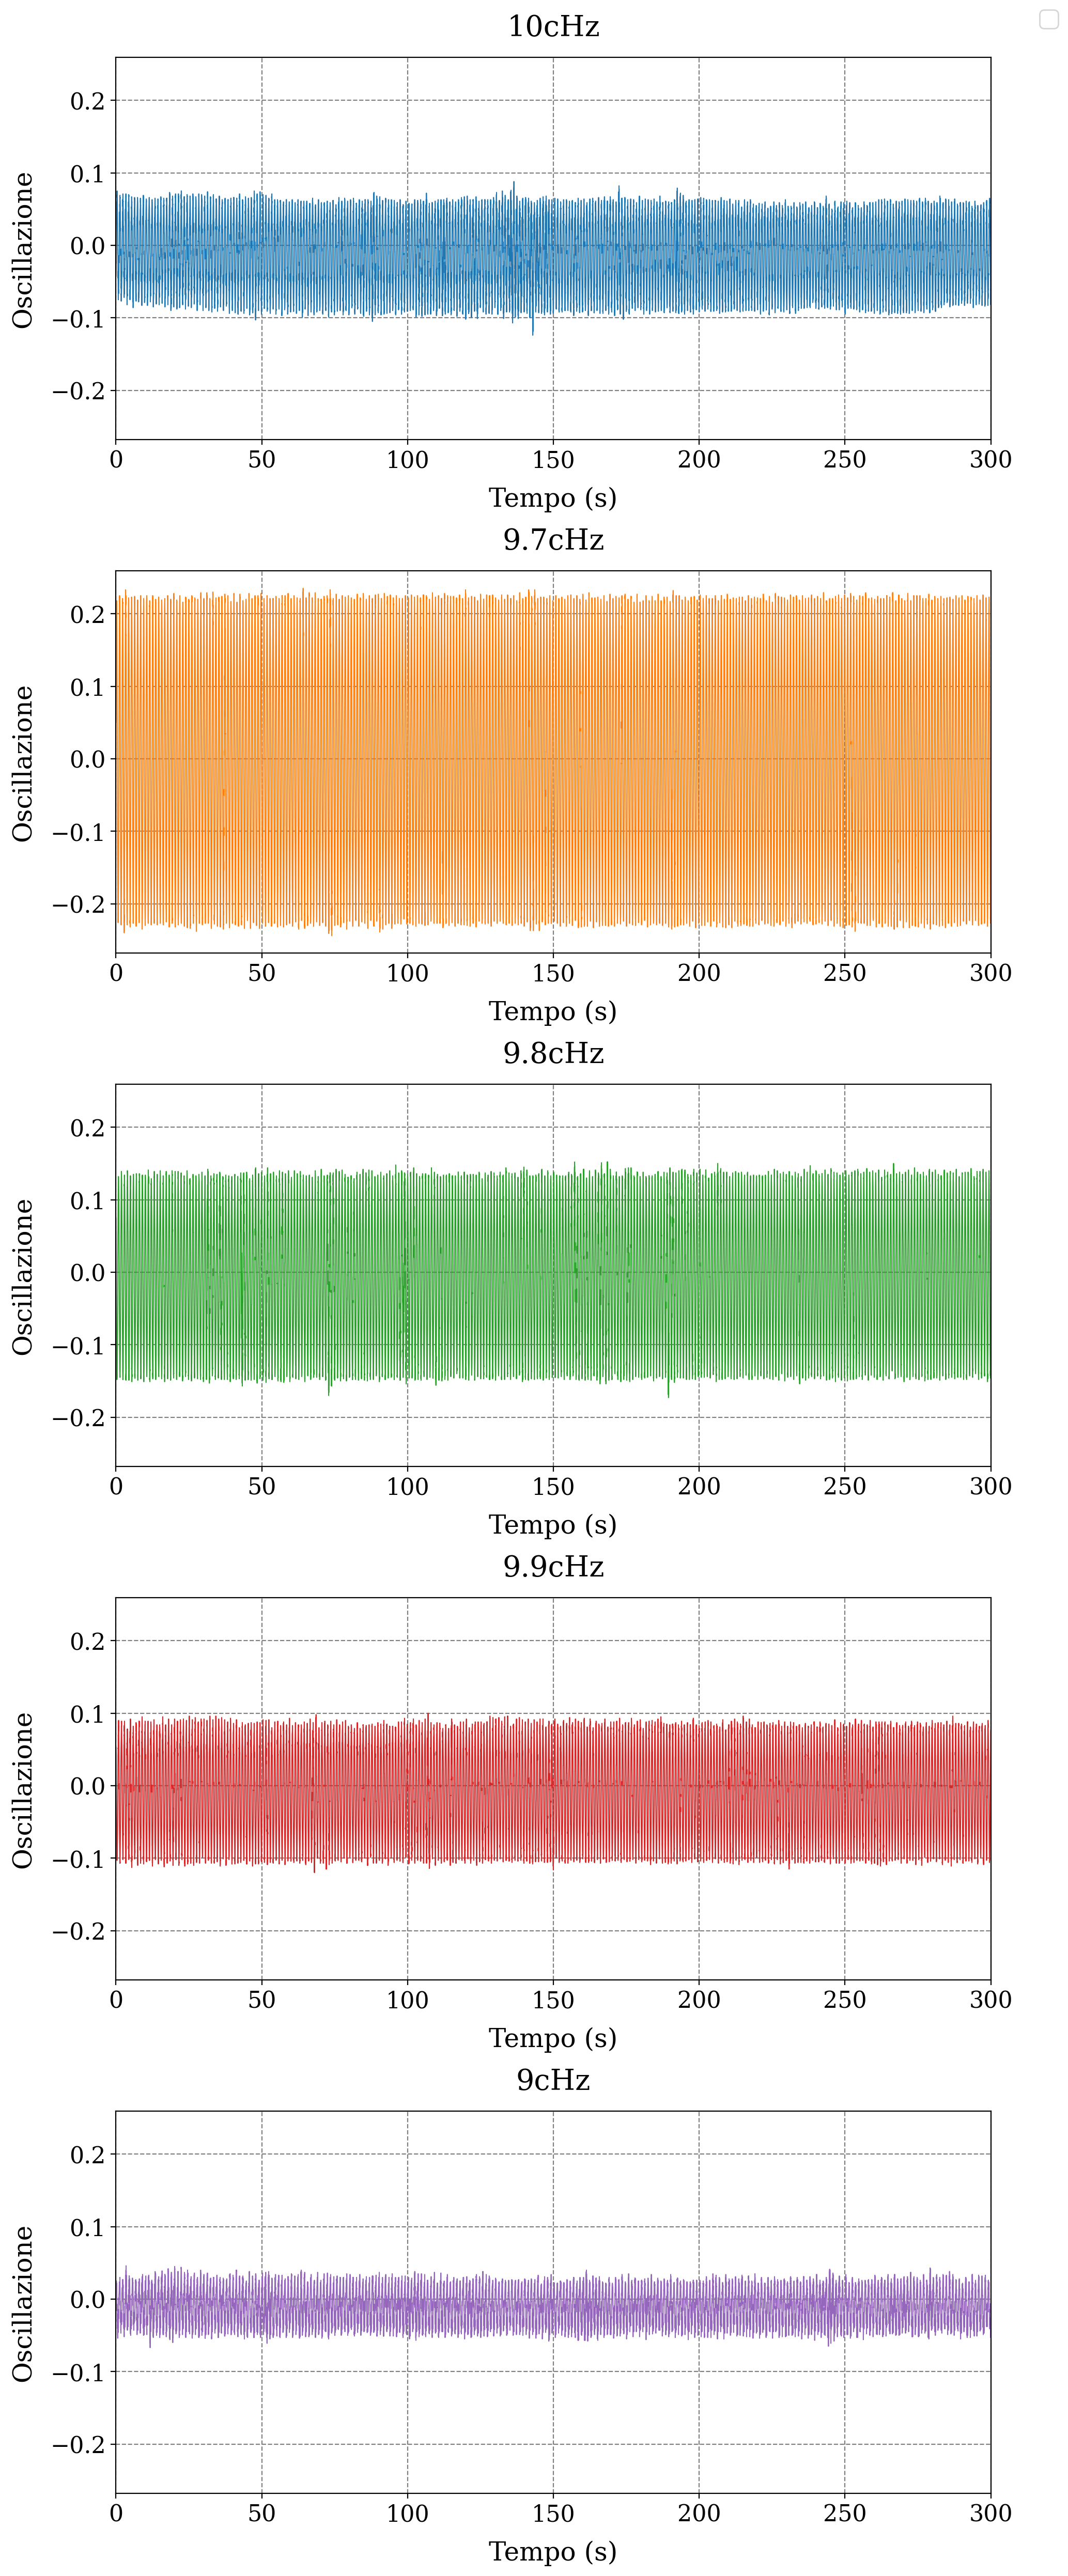

In [36]:
fig,axes = plt.subplots(len(input_files), 1, figsize=(10, 25), sharey=True)

for i, input_file in enumerate(input_files):

    ax = axes[i]

    titolo = nome(input_file)
    colore = next(color_cycle_fisso)

    x = dati[titolo]["tempo"]
    y = dati[titolo]["pendolo"]

    ax.plot(x, y, color=colore, linewidth=0.7)
    gf.parametri_grafico(ax, titolo, "Tempo (s)", "Oscillazione")
    ax.set_xlim(0,300)
gf.salva_grafico(fig, "./Images/Confronto.pdf")